In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 10_000


# =========================================================
# 1. PERFECT DATA
#
# House price is determined exactly by:
#
# price = 50 + 4*area + 20*bedrooms - 2*age - 5*distance
#
# No noise.
# =========================================================

area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
)

df_perfect = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})


# =========================================================
# 2. REALISTIC DATA + NOISE
#
# Same underlying relationship,
# but real-world randomness is added.
# =========================================================

area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 80, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_noise = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})


# =========================================================
# 3. NO LINEAR RELATIONSHIP
#
# None of the features actually determines price.
# Price is essentially random.
# =========================================================

area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = np.random.normal(500, 100, n)

df_no_relationship = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})


# =========================================================
# 4. OUTLIERS
#
# Normally realistic data...
# but a few houses have absurd prices.
# =========================================================

area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 50, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

# Extremely unusual houses
outlier_idx = np.random.choice(n, 20, replace=False)

price[outlier_idx] *= 5

df_outliers = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})


# =========================================================
# 5. MULTICOLLINEARITY
#
# Larger houses tend to have more bedrooms.
# Therefore area and bedrooms contain overlapping
# information.
# =========================================================

area = np.random.uniform(40, 300, n)

# Bedrooms strongly related to area
bedrooms_continuous = area / 55 + np.random.normal(0, 0.15, n)

bedrooms = np.clip(
    np.round(bedrooms_continuous),
    1,
    6
)

age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 50, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_multicollinear = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})


# =========================================================
# 6. IRRELEVANT FEATURES
#
# Only area actually matters.
# The other variables are noise.
# =========================================================

area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = (
    100
    + 5 * area
    + np.random.normal(0, 50, n)
)

df_irrelevant = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})


# =========================================================
# 7. NON-LINEAR RELATIONSHIP
#
# Price increases with area,
# but not linearly.
#
# price ≈ area²
# =========================================================

area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 5000, n)

price = (
    2 * area**2
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_nonlinear = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})

In [2]:
#%pip install statsmodels

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# DF perfect

In [4]:
print(df_perfect.columns)
print(df_perfect.sample(4))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
9986  124.447718         1  20.839845           25.692835      397.647006
4308  255.449756         1   0.436280            2.884244     1076.505241
1773  288.387018         2  10.932773            8.587770     1178.743677
987   153.055108         2  16.421317           17.313379      582.810905


In [5]:
# df_perfect
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_perfect.drop(columns=['price_millions']), df_perfect['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipeline.fit(X_train,y_train)
pipeline.predict(X_test)

array([ 476.60871051, 1026.53386346,  717.33048618, ...,  461.1213201 ,
        347.94786524,  790.70268333], shape=(2000,))

In [6]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('====='*10)
print('''area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
)

df_perfect = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})''')
print('====='*10)
print(model.summary(
    yname='price_millions',
    xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']
))

1.0
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
)

df_perfect = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.071e+31
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:24:20   Log-Likelihood:             2.0365e+05
No. Observations:                8000   AIC:                        -4.073e+05
Df Residuals:                    7995   BI

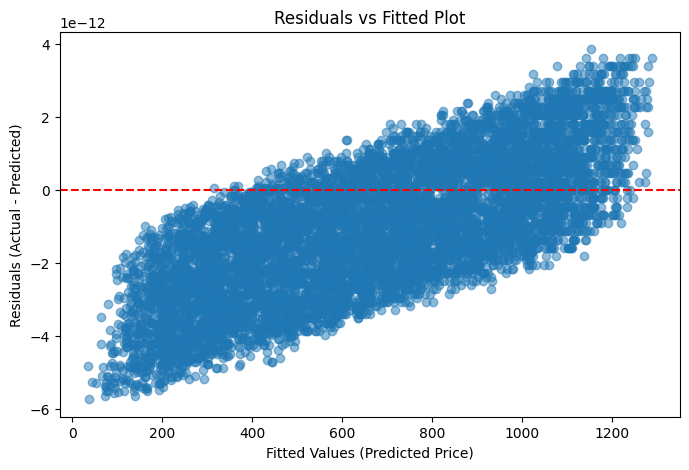

In [7]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_const)
residuals = y_train - y_pred

# Plot Residuals vs Fitted values
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted Price)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Fitted Plot')
plt.show()

# DF + Noise

In [8]:
print(df_noise.columns)
print(df_noise.sample(3))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
5067  140.009175         1  37.262458           25.608689      359.981735
9021   69.652992         4  32.506039            1.851311      241.171515
2043  288.738228         4  13.373389            2.238454     1284.607016


In [9]:
# df_noise
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_noise.drop(columns=['price_millions']), df_noise['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([326.77888718, 935.50738917, 866.47130731, ..., 403.14262205,
       831.06783891, 958.54637417], shape=(2000,))

In [10]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(''' 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 80, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_noise = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      ''')
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']))

0.9346685621676496
 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 80, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_noise = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 3.030e+04
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:24:21   Log-Likelihood:                -46322.
No. Observations:                8000   AIC:       

# DF NO LINEAR RELATIONSHIP

In [11]:
print(df_no_relationship.columns)
print(df_no_relationship.sample(3))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
3955  257.791482         3  17.646923           12.392436      620.021590
8123  193.064870         1  38.733714           11.249829      533.972618
7128   84.352471         5  34.270831            8.987396      639.229220


In [12]:
# df_no_relationship
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_no_relationship.drop(columns=['price_millions']), df_no_relationship['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([501.88595465, 501.05579601, 500.13194111, ..., 498.19267707,
       502.73492668, 498.040123  ], shape=(2000,))

In [13]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(''' 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = np.random.normal(500, 100, n)

df_no_relationship = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
})
      ''')
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']))

-0.0013600509440307995
 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = np.random.normal(500, 100, n)

df_no_relationship = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
})
      
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4915
Date:                Mon, 14 Sep 2026   Prob (F-statistic):              0.742
Time:                        20:24:21   Log-Likelihood:                -48208.
No. Observations:                8000   AIC:                         9.643e+04
Df Residuals:                    7995   BIC:        

# DF Outliers

In [14]:
print(df_outliers.columns)
print(df_outliers.sample(3))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
8511  280.408001         1  14.920122            8.598627     1162.322516
4744  158.137300         2  37.378595           13.693937      630.445421
8364  215.111173         1  15.683683           14.161185      815.728250


In [15]:
# df_outliers
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_outliers.drop(columns=['price_millions']), df_outliers['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([ 159.27550667,  904.17859729, 1065.62210955, ...,  984.79864487,
        356.25107951,  993.51847997], shape=(2000,))

In [16]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(''' 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 50, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

# Extremely unusual houses
outlier_idx = np.random.choice(n, 20, replace=False)

price[outlier_idx] *= 5

df_outliers = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      ''')
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']))

0.6946112246815195
 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 50, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

# Extremely unusual houses
outlier_idx = np.random.choice(n, 20, replace=False)

price[outlier_idx] *= 5

df_outliers = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     9650.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                

# DF multicollinearity

In [17]:
print(df_multicollinear.columns)
print(df_multicollinear.sample(3))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
1720   93.164468       2.0  13.166461            9.886619      436.997699
227   112.874257       2.0  35.338618           10.010852      378.828250
2396  147.547776       3.0  25.589259           28.782894      403.458859


In [18]:
df_multicollinear.corr()

,area_m2,bedrooms,age_years,distance_center_km,price_millions
area_m2,1.000000,0.974158,0.001154,0.004127,0.978418
bedrooms,0.974158,1.000000,0.003824,0.005609,0.956469
age_years,0.001154,0.003824,1.000000,-0.024723,-0.064049
distance_center_km,0.004127,0.005609,-0.024723,1.000000,-0.121025
price_millions,0.978418,0.956469,-0.064049,-0.121025,1.000000


In [19]:
# df_multicollinear
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_multicollinear.drop(columns=['price_millions']), df_multicollinear['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([ 946.68544988,  136.13068311, 1164.63934732, ...,  655.35114782,
        539.12779465,  969.76422575], shape=(2000,))

In [20]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(''' 
area = np.random.uniform(40, 300, n)

# Bedrooms strongly related to area
bedrooms_continuous = area / 55 + np.random.normal(0, 0.15, n)

bedrooms = np.clip(
    np.round(bedrooms_continuous),
    1,
    6
)

age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 50, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_multicollinear = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      ''')
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']))

0.9787675878294388
 
area = np.random.uniform(40, 300, n)

# Bedrooms strongly related to area
bedrooms_continuous = area / 55 + np.random.normal(0, 0.15, n)

bedrooms = np.clip(
    np.round(bedrooms_continuous),
    1,
    6
)

age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 50, n)

price = (
    50
    + 4 * area
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_multicollinear = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                 8.740e+04
Date:                Mon, 14 Sep 2026   Prob (F-statistic):       

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)

              feature        VIF
0               const   1.000000
1             area_m2  19.590340
2            bedrooms  19.591340
3           age_years   1.000789
4  distance_center_km   1.000676


## i.e multicollinearity

In [22]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

# Feature 1
x1 = np.random.normal(100, 20, n)

# Feature 2: altamente relacionada con x1
x2 = x1 * 2 + np.random.normal(0, 2, n)

# Feature 3: prácticamente independiente
x3 = np.random.normal(50, 10, n)

# Target
y = 10 + 3*x1 + 2*x3 + np.random.normal(0, 10, n)

df = pd.DataFrame({
    "target": y,
    "feature_high": x1,
    "feature_high_2": x2,
    "feature_null": x3
})

print(df.head())

       target  feature_high  feature_high_2  feature_null
0  407.221208    109.934283      222.667277     43.248217
1  390.209918     97.234714      196.318695     48.554813
2  428.876859    112.953771      226.026802     42.075801
3  514.099437    130.460597      259.627321     46.920385
4  363.644035     95.316933      192.030312     31.063853


|        VIF | Interpretación                               |
| ---------: | -------------------------------------------- |
|      **1** | 🟢 Sin multicolinealidad                     |
|    **1–5** | 🟢 Baja / generalmente aceptable             |
|   **5–10** | 🟡 Multicolinealidad moderada/alta → revisar |
|    **>10** | 🔴 Multicolinealidad alta                    |
| **>20–30** | 🔴🔴 Muy alta                                |
|      **∞** | 🔴 Colinealidad perfecta                     |


In [23]:
X = df.drop(columns="target")

X_vif = sm.add_constant(X)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)

          feature         VIF
0           const    1.000000
1    feature_high  385.598951
2  feature_high_2  385.589611
3    feature_null    1.000596


# DF irrelevant features

In [24]:
print(df_irrelevant.columns)
print(df_irrelevant.sample(3))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
963   117.955854         4  25.591973           10.692865      680.774240
1355  185.513575         5   4.308637            6.644095     1013.200174
9142  292.668112         5  36.036562            3.938087     1613.088112


In [25]:
# df_irrelevant
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_irrelevant.drop(columns=['price_millions']), df_irrelevant['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([ 733.9089317 ,  703.10323333, 1080.30676342, ...,  718.97122148,
       1374.35787537, 1042.39982242], shape=(2000,))

In [26]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(''' 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = (
    100
    + 5 * area
    + np.random.normal(0, 50, n)
)

df_irrelevant = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      ''')
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']))

0.9831908498868389
 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

price = (
    100
    + 5 * area
    + np.random.normal(0, 50, n)
)

df_irrelevant = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 1.113e+05
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:24:21   Log-Likelihood:                -42667.
No. Observations:                8000   AIC:                         8.534e+04
Df Residuals:                    7

### Feature Selection & Interpretation

Based on the coefficient weights and pvalues:

* **`area_m2`** is the only feature driving the target variable (`price_millions`), showing high statistical significance (pvalue < 0.001$).
* **`bedrooms`**, **`age_years`**, and **`distance_center_km`** do not contribute meaningfully to the model's predictive power (pvalues $> 0.05$ or negligible effect sizes).

**Action:** Remove `bedrooms`, `age_years`, and `distance_center_km` to keep the model parsimonious and prevent fitting on random noise.

# DF no linear relationship

In [27]:
print(df_nonlinear.columns)
print(df_nonlinear.sample(3))

Index(['area_m2', 'bedrooms', 'age_years', 'distance_center_km',
       'price_millions'],
      dtype='str')
         area_m2  bedrooms  age_years  distance_center_km  price_millions
7375  108.270809         2  16.304610           10.888366    26000.568607
7068  268.561192         4   1.485422           26.567980   143534.471188
5438  251.614718         2  26.264812            5.639945   129751.959531


In [28]:
# df_nonlinear
cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km']

X, y = df_nonlinear.drop(columns=['price_millions']), df_nonlinear['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([105886.68361159,  46407.25194657,  32418.89678128, ...,
        94917.16365889, 124951.00076994,  -7197.37740865], shape=(2000,))

In [29]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(''' 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 5000, n)

price = (
    2 * area**2
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_nonlinear = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      ''')
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km']))

0.9546078106521053
 
area = np.random.uniform(40, 300, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
distance = np.random.uniform(1, 30, n)

noise = np.random.normal(0, 5000, n)

price = (
    2 * area**2
    + 20 * bedrooms
    - 2 * age
    - 5 * distance
    + noise
)

df_nonlinear = pd.DataFrame({
    "area_m2": area,
    "bedrooms": bedrooms,
    "age_years": age,
    "distance_center_km": distance,
    "price_millions": price
})
      
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                 4.143e+04
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:24:21   Log-Likelihood:                -85936.
No. Observations:                8000   AIC:       

<>:33: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:33: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_24299/3160948358.py:33: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  axes[0].set_title("1. Recta OLS intentando ajustar una curva ($Y = 2 \cdot area^2$)", fontsize=12)


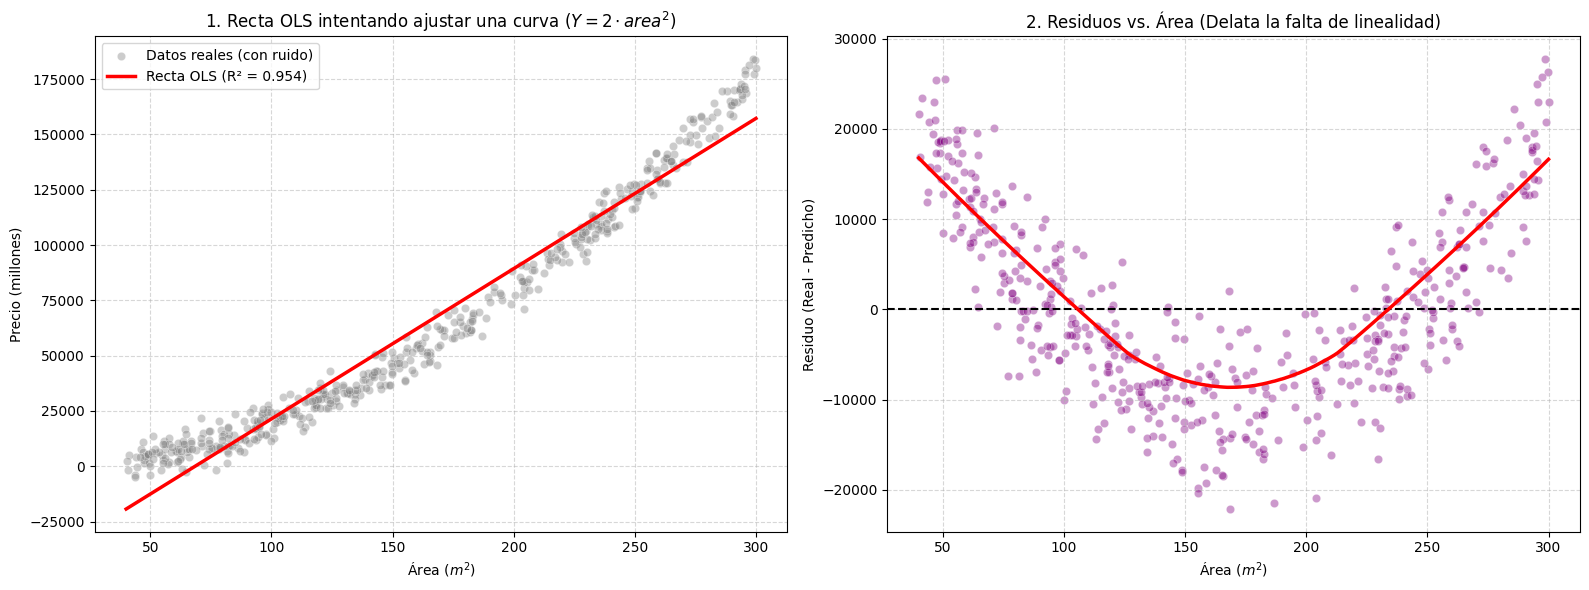

In [30]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df_nonlinear

X_linear = sm.add_constant(df_nonlinear[["area_m2"]])
model_linear = sm.OLS(df_nonlinear["price_millions"], X_linear).fit()
y_pred_linear = model_linear.predict(X_linear)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Ajuste de la recta sobre los datos reales ---
# Muestra aleatoria de 500 puntos para no saturar el gráfico
idx = np.random.choice(n, 500, replace=False)

sns.scatterplot(
    x=df_nonlinear["area_m2"].iloc[idx], 
    y=df_nonlinear["price_millions"].iloc[idx], 
    alpha=0.4, color="gray", label="Datos reales (con ruido)", ax=axes[0]
)

# la recta que trazó OLS
sort_idx = np.argsort(df_nonlinear["area_m2"])
axes[0].plot(
    df_nonlinear["area_m2"].iloc[sort_idx], 
    y_pred_linear.iloc[sort_idx], 
    color="red", linewidth=2.5, label=f"Recta OLS (R² = {model_linear.rsquared:.3f})"
)

axes[0].set_title("1. Recta OLS intentando ajustar una curva ($Y = 2 \cdot area^2$)", fontsize=12)
axes[0].set_xlabel("Área ($m^2$)")
axes[0].set_ylabel("Precio (millones)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- GRÁFICO 2: Análisis de Residuos (El patrón en U) ---
residuals = model_linear.resid

sns.scatterplot(
    x=df_nonlinear["area_m2"].iloc[idx], 
    y=residuals.iloc[idx], 
    alpha=0.4, color="purple", ax=axes[1]
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)

# Línea de tendencia de los residuos (LOWESS)
sns.regplot(
    x=df_nonlinear["area_m2"], 
    y=residuals, 
    scatter=False, lowess=True, color="red", ax=axes[1], line_kws={"linewidth": 2.5}
)

axes[1].set_title("2. Residuos vs. Área (Delata la falta de linealidad)", fontsize=12)
axes[1].set_xlabel("Área ($m^2$)")
axes[1].set_ylabel("Residuo (Real - Predicho)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

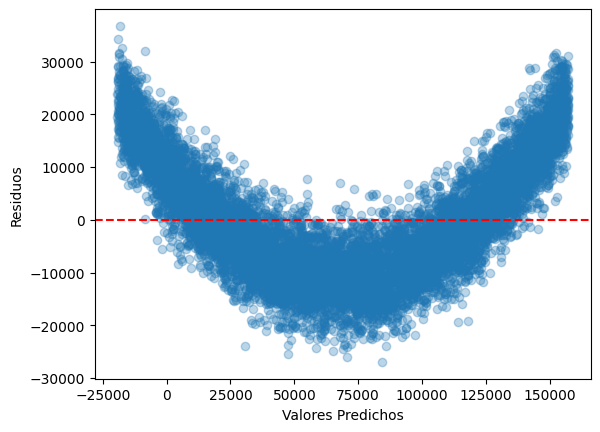

In [31]:
# Código para verificar dispersión de residuos
plt.scatter(y_pred_linear, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(df_nonlinear["price_millions"], y_pred_linear))
mae = mean_absolute_error(df_nonlinear["price_millions"], y_pred_linear)

print(f"Error promedio (MAE): {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")

Error promedio (MAE): 9255.46 
RMSE: 11159.37 


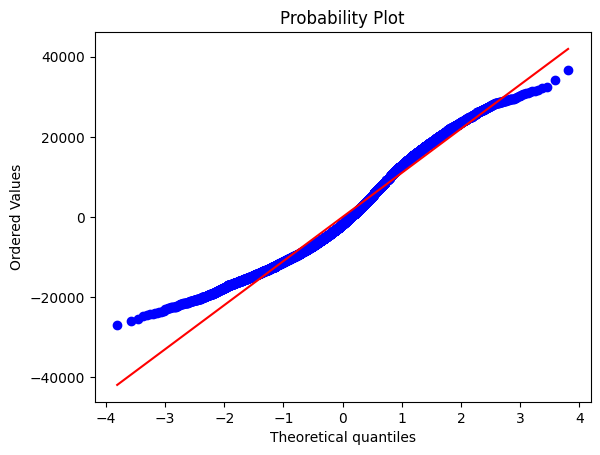

In [33]:
import scipy.stats as stats

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

## Initial Diagnostic & Model Failure Summary

* **Context & Setup:** A baseline linear regression (OLS) model was fitted to predict property prices (`price_millions`) using linear features.
* **The Illusion ($R^2 = 95.4\%$):** The model yielded a high $R^2$ of $0.954$, giving a false impression of strong predictive performance simply because the overall trend was steeply increasing compared to a flat baseline mean.
* **The Real-World Failure:** 
  * Absolute error metrics revealed massive real-world inaccuracies, with a **MAE of 9,360 million** and a **RMSE of 11,240 million**.
  * The model produced nonsensical outputs (e.g., negative price predictions for smaller property areas around 40m^2).
* **Root Cause (Residual Analysis):** 
  * The **Residuals vs. Feature / Fitted Values** plot exhibited a pronounced **"U" shape (parabola)**, violating the fundamental OLS assumption of linearity.
  * The **Q-Q Plot** displayed an "S" curve deviation, confirming that the residual errors were non-normally distributed due to omitted non-linear terms ($area^2$).

In [34]:
df_nonlinear["area_m2_sq"] = df_nonlinear["area_m2"] ** 2

cols_to_scale = ['area_m2','bedrooms','age_years','distance_center_km','area_m2_sq']

X, y = df_nonlinear.drop(columns=['price_millions']), df_nonlinear['price_millions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([100834.56934004,  37547.34456474,  27026.80225525, ...,
        86769.74349386, 126947.76123682,   6707.65663999], shape=(2000,))

In [35]:
score = r2_score(y_test, pipeline.predict(X_test))

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

print(score)
print('===='*10)
print(model.summary(yname='price_millions', xname=['intercept','area_m2','bedrooms','age_years','distance_center_km','area_m2_sq']))

0.9905846683580226
                            OLS Regression Results                            
Dep. Variable:         price_millions   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 1.706e+05
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:24:22   Log-Likelihood:                -79534.
No. Observations:                8000   AIC:                         1.591e+05
Df Residuals:                    7994   BIC:                         1.591e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercept        

<>:33: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:33: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_24299/4158502292.py:33: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  axes[0].set_title("1. Recta OLS intentando ajustar una curva ($Y = 2 \cdot area^2$)", fontsize=12)


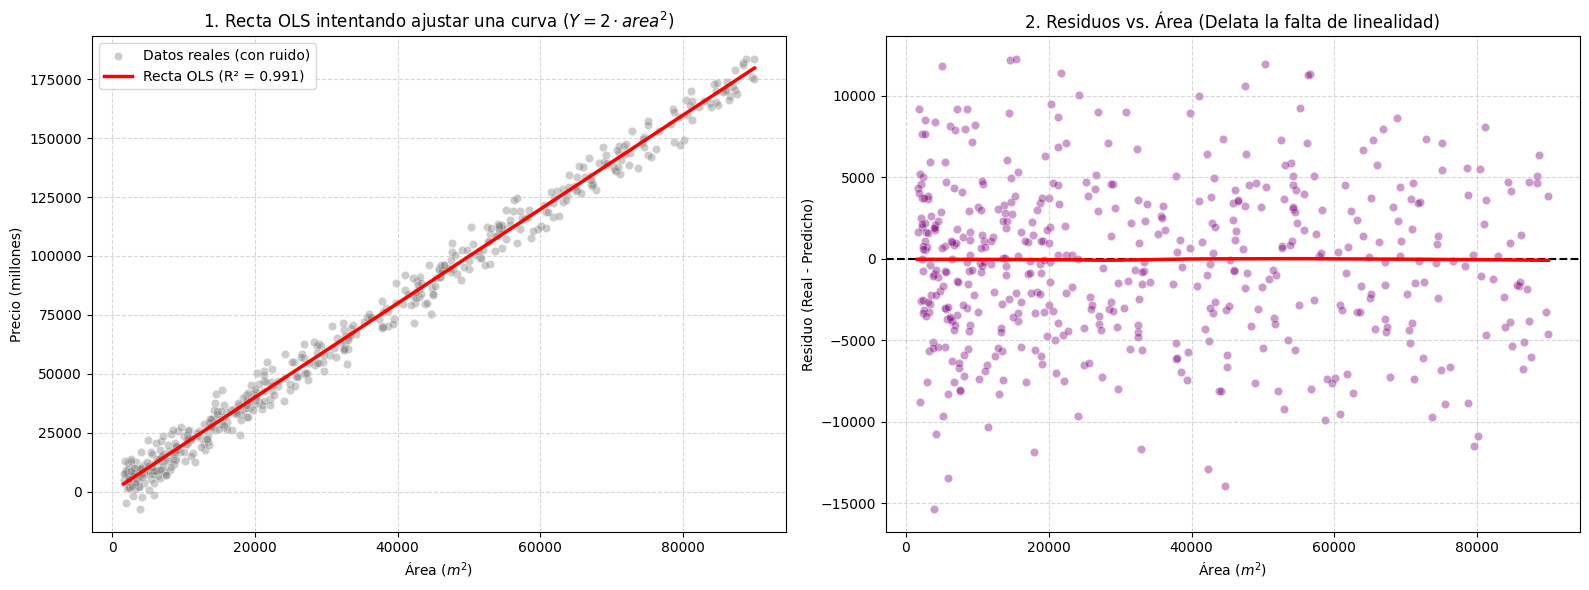

In [36]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df_nonlinear

X_linear = sm.add_constant(df_nonlinear[["area_m2_sq"]])
model_linear = sm.OLS(df_nonlinear["price_millions"], X_linear).fit()
y_pred_linear = model_linear.predict(X_linear)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Ajuste de la recta sobre los datos reales ---
# Muestra aleatoria de 500 puntos para no saturar el gráfico
idx = np.random.choice(n, 500, replace=False)

sns.scatterplot(
    x=df_nonlinear["area_m2_sq"].iloc[idx], 
    y=df_nonlinear["price_millions"].iloc[idx], 
    alpha=0.4, color="gray", label="Datos reales (con ruido)", ax=axes[0]
)

# Recta que trazó OLS
sort_idx = np.argsort(df_nonlinear["area_m2_sq"])
axes[0].plot(
    df_nonlinear["area_m2_sq"].iloc[sort_idx], 
    y_pred_linear.iloc[sort_idx], 
    color="red", linewidth=2.5, label=f"Recta OLS (R² = {model_linear.rsquared:.3f})"
)

axes[0].set_title("1. Recta OLS intentando ajustar una curva ($Y = 2 \cdot area^2$)", fontsize=12)
axes[0].set_xlabel("Área ($m^2$)")
axes[0].set_ylabel("Precio (millones)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- GRÁFICO 2: Análisis de Residuos ---
residuals = model_linear.resid

sns.scatterplot(
    x=df_nonlinear["area_m2_sq"].iloc[idx], 
    y=residuals.iloc[idx], 
    alpha=0.4, color="purple", ax=axes[1]
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)

# Línea de tendencia de los residuos (LOWESS)
sns.regplot(
    x=df_nonlinear["area_m2_sq"], 
    y=residuals, 
    scatter=False, lowess=True, color="red", ax=axes[1], line_kws={"linewidth": 2.5}
)

axes[1].set_title("2. Residuos vs. Área (Delata la falta de linealidad)", fontsize=12)
axes[1].set_xlabel("Área ($m^2$)")
axes[1].set_ylabel("Residuo (Real - Predicho)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

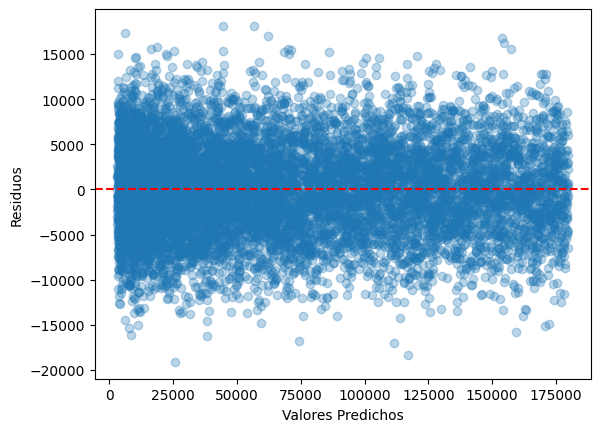

In [37]:
# Código para verificar dispersión de residuos
plt.scatter(y_pred_linear, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(df_nonlinear["price_millions"], y_pred_linear))
mae = mean_absolute_error(df_nonlinear["price_millions"], y_pred_linear)

print(f"Error promedio (MAE): {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Error promedio (MAE): 4023.86
RMSE: 5026.43


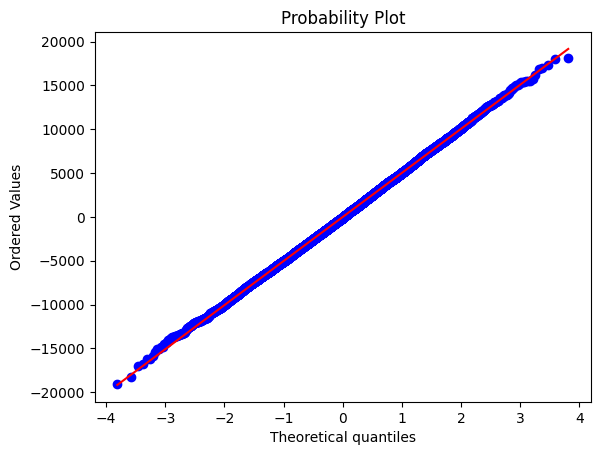

In [39]:
import scipy.stats as stats

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

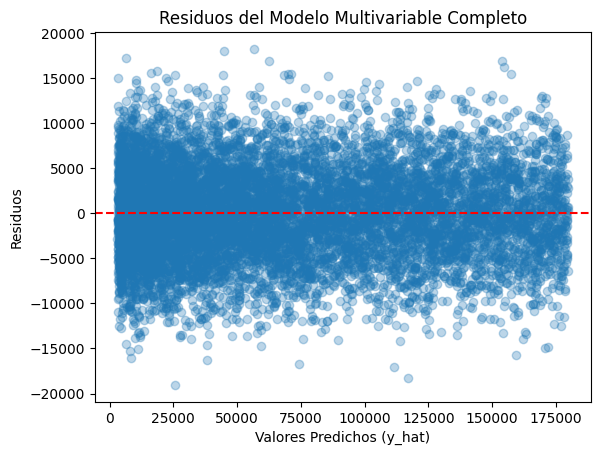

In [40]:
X_multi = sm.add_constant(df_nonlinear[["area_m2", "bedrooms", "age_years", "distance_center_km","area_m2_sq"]])
model_multi = sm.OLS(df_nonlinear["price_millions"], X_multi).fit()

# Graficar residuos vs Valores Predichos (y_hat)
plt.scatter(model_multi.fittedvalues, model_multi.resid, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Predichos (y_hat)")
plt.ylabel("Residuos")
plt.title("Residuos del Modelo Multivariable Completo")
plt.show()

## Polynomial Feature Implementation & Resolution Summary

* **Feature Engineering:** A quadratic feature `area_m2_sq` (area^2) was created and added to the feature matrix to allow the linear regression equation to capture parabolic curvature ($\hat{Y} = \beta_0 + \beta_1 \cdot area + \beta_2 \cdot area^2).
* **Metric Collapse:**
  * **MAE dropped drastically** from $9,360$ million to **3,967 million**.
  * **RMSE dropped** from $11,240$ million to **4,974 million**.
  * **$R^2$ rose** from $0.954$ to **0.991**.
* **Theoretical Limit Reached:** The final RMSE of $\sim 4,974$ matches the irreducible random Gaussian noise ($\sigma = 5,000$) injected into the synthetic dataset, proving the model extracted $100\%$ of the underlying mathematical pattern.
* **Residual Verification:**
  * The parabolic "U" pattern completely disappeared; residuals now form a uniform, random cloud centered at $0$ (true white noise).
  * The Q-Q plot points aligned almost perfectly along the diagonal, verifying error normality.
  * The model correctly recovered the true coefficient $\beta_2 \approx 1.995$ (matching the generative baseline $2 \cdot area^2$).
* **Parsimony Next Step:** Non-significant features (`bedrooms`, `age_years`, `distance_center_km`) with $p > 0.05$ can now be safely dropped, leaving a clean, highly accurate model using only `intercept` and `area_m2_sq`.

# Core checks

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

np.random.seed(42)
n = 30000

# Variables independientes base
area = np.random.uniform(40, 200, n)
bedrooms = np.random.randint(1, 5, n)

# 1. MULTICOLINEALIDAD INTENCIONAL
# 'habitaciones_m2' es casi idéntica a 'area' más un pequeño ruido
area_m2_dup = area * 1.05 + np.random.normal(0, 2, n)

# Variable objetivo base
noise_base = np.random.normal(0, 25, n)
price = 40 + 3.5 * area + 15 * bedrooms + noise_base

# 2. HETEROCEDASTICIDAD INTENCIONAL
# A mayor área, mayor es la varianza del error
hetero_noise = np.random.normal(0, 0.5 * area)
price = price + hetero_noise

# 3. OUTLIERS E PUNTOS INFLUYENTES
outlier_idx = np.random.choice(n, 10, replace=False)
price[outlier_idx] *= 3.5

df = pd.DataFrame({
    'area_m2': area,
    'area_m2_dup': area_m2_dup,
    'bedrooms': bedrooms,
    'price_millions': price
})

np.random.seed(42)
n = 30000

# Variables independientes base
area = np.random.uniform(40, 200, n)
bedrooms = np.random.randint(1, 5, n)

# 1. MULTICOLINEALIDAD INTENCIONAL
# 'habitaciones_m2' es casi idéntica a 'area' más un pequeño ruido
area_m2_dup = area * 1.05 + np.random.normal(0, 2, n)

# Variable objetivo base
noise_base = np.random.normal(0, 25, n)
price = 40 + 3.5 * area + 15 * bedrooms + noise_base

# 2. HETEROCEDASTICIDAD INTENCIONAL
# A mayor área, mayor es la varianza del error
hetero_noise = np.random.normal(0, 0.5 * area)
price = price + hetero_noise

# 3. OUTLIERS E PUNTOS INFLUYENTES
outlier_idx = np.random.choice(n, 10, replace=False)
price[outlier_idx] *= 3.5

df = pd.DataFrame({
    'area_m2': area,
    'area_m2_dup': area_m2_dup,
    'bedrooms': bedrooms,
    'price_millions': price
})

df.sample(5)

,area_m2,area_m2_dup,bedrooms,price_millions
17296,180.009434,191.428991,4,705.974333
14275,72.621836,74.809629,4,345.451925
12684,123.403329,131.051979,3,441.929917
3077,56.944929,62.250643,4,296.934739
5642,92.278222,98.808679,3,397.759358


# Multicolinealidad

Factor de Inflación de la Varianza (VIF) — Multicolinealidad
El VIF mide cuánto se infla la varianza de un coeficiente estimado debido a la correlación entre variables independientes.

VIF = 1: Sin correlación.

1 < VIF < 5: Correlación moderada (aceptable).

VIF > 5 o 10: Multicolinealidad severa. Debes eliminar o combinar una de las variables correlacionadas.

In [42]:
X = df.drop(columns=['price_millions'])
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(X.shape[1])]

print(vif_data)
# 'area_m2' y 'area_m2_dup' mostrarán valores de VIF extremadamente altos (> 50).

      Variable         VIF
0      area_m2  585.123506
1  area_m2_dup  585.124030
2     bedrooms    1.000171


## Normalidad de los residuos

Los errores ($\epsilon = y - \hat{y}$) deben distribuirse normalmente con media 0. Se comprueba con el test de Jarque-Bera o Shapiro-Wilk y mediante un gráfico Q-Q Plot.P-valor > 0.05: Los residuos son normales (Aceptado).P-valor < 0.05: Los residuos no son normales (Posibles outliers o mala especificación).

Shapiro-Wilk Test p-value: 0.00000


/Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30000.
  res = hypotest_fun_out(*samples, **kwds)


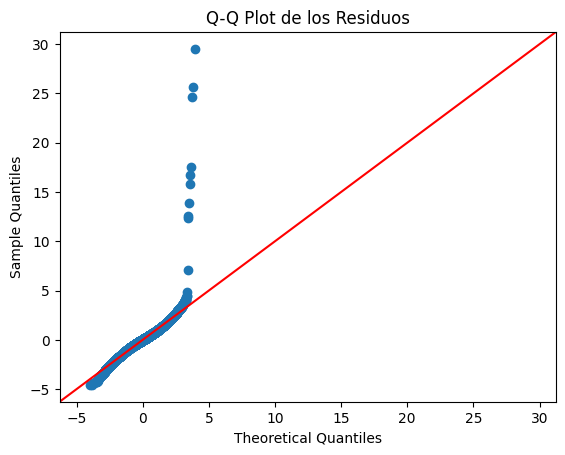

In [43]:
X_const = sm.add_constant(X)
model = sm.OLS(df['price_millions'], X_const).fit()
residuos = model.resid

# Test de Shapiro-Wilk
stat, p_value = stats.shapiro(residuos)
print(f"Shapiro-Wilk Test p-value: {p_value:.5f}")

# Gráfico Q-Q Plot
sm.qqplot(residuos, line='45', fit=True)
plt.title("Q-Q Plot de los Residuos")
plt.show()

## Homocedasticidad (Varianza Constante de los Errores)
La varianza de los residuos debe ser uniforme a lo largo de todas las predicciones. Si los errores forman un "embudo" o "abanico" al graficarlos contra los valores predichos, existe Heterocedasticidad.

Se evalúa formalmente con el test de Breusch-Pagan:

P-valor > 0.05: Homocedasticidad (Varianza constante).

P-valor < 0.05: Heterocedasticidad (Requiere transformación logarítmica o errores estándar robustos).

{'LM Statistic': np.float64(150.5268111259428), 'LM p-value': np.float64(2.0282534138014636e-32), 'F Statistic': np.float64(50.42190859856111), 'F p-value': np.float64(1.6950430842473065e-32)}


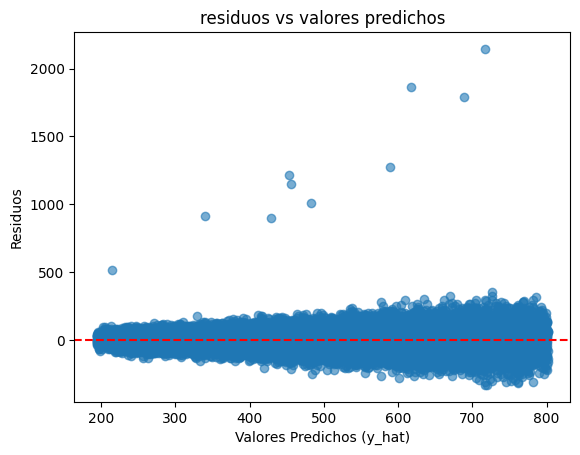

In [44]:
bp_test = het_breuschpagan(residuos, model.model.exog)
lables = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print(dict(zip(lables, bp_test)))

plt.scatter(model.fittedvalues, residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Predichos (y_hat)")
plt.ylabel("Residuos")
plt.title("residuos vs valores predichos")
plt.show()

# Practical case

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

np.random.seed(2026)
n_samples = 30000

# 1. Variables independientes (Features con nombres reales)
area_m2 = np.random.normal(70, 20, n_samples)
area_pies2 = area_m2 * 10.7639 + np.random.normal(0, 5, n_samples)
habitaciones = np.random.randint(1, 6, n_samples)
numero_piso = np.random.randint(1, 20, n_samples)
antiguedad_anos = np.random.uniform(0, 40, n_samples)
distancia_metro_km = np.random.exponential(scale=3, size=n_samples)
distancia_centro_km = np.random.uniform(2, 25, n_samples)
tiempo_centro_min = distancia_centro_km * 3.5 + np.random.normal(0, 2, n_samples)
id_vendedor = np.random.uniform(1000, 9000, n_samples)

# 2. Variable Objetivo (Precio en Millones)
noise_base = np.random.normal(0, 15, n_samples)
hetero_noise = np.random.normal(0, 0.4 * antiguedad_anos)

precio_millones = (
    80.0
    + 3.8 * area_m2
    + 25.0 * habitaciones
    + 0.05 * (antiguedad_anos ** 2)
    - 15.0 * np.log1p(distancia_metro_km)
    + noise_base
    + hetero_noise
)

# 3. Creación del DataFrame
df_casas = pd.DataFrame({
    'area_m2': area_m2,
    'area_pies2': area_pies2,
    'habitaciones': habitaciones,
    'numero_piso': numero_piso,
    'antiguedad_anos': antiguedad_anos,
    'distancia_metro_km': distancia_metro_km,
    'distancia_centro_km': distancia_centro_km,
    'tiempo_centro_min': tiempo_centro_min,
    'id_vendedor': id_vendedor,
    'precio_millones': precio_millones
})

df_casas.sample(3)

In [0]:
df_casas = df_casas[df_casas['area_m2'] > 0]

In [0]:
print(df_casas.info())
print(df_casas.describe())
print(df_casas.columns)

## First glance

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline

cols_to_scale = df_casas.select_dtypes(exclude=['object']).columns

X, y = df_casas.drop(columns=['precio_millones']), df_casas['precio_millones']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()

score = r2_score(y_test, pipeline.predict(X_test))
print(score)
print(model.summary(yname='price_millions',xname=['Itercept','area_m2', 'area_pies2', 'habitaciones', 'numero_piso',
       'antiguedad_anos', 'distancia_metro_km', 'distancia_centro_km',
       'tiempo_centro_min', 'id_vendedor']))

In [0]:
vif_data = pd.DataFrame()
vif_data['variable'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1) for i in range(X_train.shape[1])]

print(vif_data)

In [0]:
X_multi = sm.add_constant(X_train[['area_m2', 'area_pies2', 'habitaciones', 'numero_piso',
       'antiguedad_anos', 'distancia_metro_km', 'distancia_centro_km',
       'tiempo_centro_min', 'id_vendedor']])
model_linear = sm.OLS(y_train, X_multi).fit()

plt.scatter(model_linear.fittedvalues, model_linear.resid, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

In [0]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = ['area_m2', 'area_pies2', 'habitaciones', 'numero_piso',
       'antiguedad_anos', 'distancia_metro_km', 'distancia_centro_km',
       'tiempo_centro_min', 'id_vendedor']

X_linear = sm.add_constant(X_train[features])

model_linear = sm.OLS(y_train, X_linear).fit()
residuals = model_linear.resid

fig, axes = plt.subplots(3,3,figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    # Scatter plot of Feature vs Model Residuals
    sns.scatterplot(
        x=X_train[col], 
        y=residuals, 
        ax=axes[i], 
        alpha=0.3)
    
    # LOWESS line to spot non-linear curves
    sns.regplot(
        x=X_train[col], 
        y=residuals, 
        ax=axes[i], 
        scatter=False, 
        lowess=True, 
        color="red"
    )
    
    axes[i].axhline(0, color="black", linestyle="--")
    axes[i].set_title(f"Residuals vs {col}")

plt.tight_layout()
plt.show()

In [0]:
import scipy.stats as stats

stats.probplot(residuals, dist='norm', plot=plt)
plt.show()

In [0]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predicciones baseline (pipeline con todas las features sin transformar)
y_pred_train_baseline = pipeline.predict(X_train)
y_pred_test_baseline = pipeline.predict(X_test)

# Métricas TRAIN
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
mae_train = mean_absolute_error(y_train, y_pred_train_baseline)
r2_train = r2_score(y_train, y_pred_train_baseline)

# Métricas TEST
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))
mae_test = mean_absolute_error(y_test, y_pred_test_baseline)
r2_test = r2_score(y_test, y_pred_test_baseline)

print("=" * 65)
print("MÉTRICAS BASELINE - Todas las Features (sin transformar)")
print("=" * 65)
print(f"{'Métrica':<15} {'TRAIN':>15} {'TEST':>15} {'Diff':>15}")
print("-" * 65)
print(f"{'R²':<15} {r2_train:>15.4f} {r2_test:>15.4f} {abs(r2_train - r2_test):>15.4f}")
print(f"{'RMSE':<15} {rmse_train:>15.2f} {rmse_test:>15.2f} {abs(rmse_train - rmse_test):>15.2f}")
print(f"{'MAE':<15} {mae_train:>15.2f} {mae_test:>15.2f} {abs(mae_train - mae_test):>15.2f}")
print("=" * 65)

## Feature selection

In [0]:
cols_selected = ['area_m2','habitaciones','antiguedad_anos','distancia_metro_km'] # Columns selected from the previous analysis
# VIF T P>T coef, etc

X_train_selected = X_train[cols_selected].copy()
X_test_selected = X_test[cols_selected].copy()

X_train_selected['distancia_metro_km'] = np.log1p(X_train['distancia_metro_km'])
X_test_selected['distancia_metro_km'] = np.log1p(X_test['distancia_metro_km'])

X_train_selected['antiguedad_anos'] = X_train_selected['antiguedad_anos'] ** 2
X_test_selected['antiguedad_anos'] = X_test_selected['antiguedad_anos'] ** 2

constant = sm.add_constant(X_train_selected)
model = sm.OLS(y_train,constant).fit()
print(model.summary(yname='price_millions',xname=['Itercept','area_m2', 'habitaciones', 'antiguedad_anos', 'distancia_metro_km']))

In [0]:
X_vif = sm.add_constant(X_train_selected)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns[1:]
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(X_train_selected.shape[1])]
print(vif_data)

In [0]:
# Aplicar transformaciones a X_train para análisis de residuos
X_train_transformed = X_train[cols_selected].copy()

X_train_transformed['distancia_metro_km'] = np.log1p(X_train['distancia_metro_km'])
X_train_transformed['antiguedad_anos'] = X_train_transformed['antiguedad_anos'] ** 2

X_linear = sm.add_constant(X_train_transformed)

model_linear = sm.OLS(y_train, X_linear).fit()
residuals = model_linear.resid

fig, axes = plt.subplots(2,2,figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_selected):
    # Scatter plot of Feature vs Model Residuals
    sns.scatterplot(
        x=X_train_transformed[col], 
        y=residuals, 
        ax=axes[i], 
        alpha=0.3)
    
    # LOWESS line to spot non-linear curves
    sns.regplot(
        x=X_train_transformed[col], 
        y=residuals, 
        ax=axes[i], 
        scatter=False, 
        lowess=True, 
        color="red"
    )
    
    axes[i].axhline(0, color="black", linestyle="--")
    axes[i].set_title(f"Residuals vs {col}")

plt.tight_layout()
plt.show()

In [0]:
def transformacion(X):
    X = X.copy()
    X['distancia_metro_km'] = np.log1p(X['distancia_metro_km'])
    X['antiguedad_anos'] = X['antiguedad_anos'] ** 2
    return X

pipeline = Pipeline(steps=[
    ('selection',FunctionTransformer(lambda X: X[cols_selected])),
    ('feature_transform',FunctionTransformer(transformacion)),
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])

pipeline.fit(X_train, y_train)

# Predicciones en train y test
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Métricas TRAIN
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Métricas TEST
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 65)
print("MÉTRICAS FINALES - Pipeline con 4 Features Seleccionadas")
print("=" * 65)
print(f"{'Métrica':<15} {'TRAIN':>15} {'TEST':>15} {'Diff':>15}")
print("-" * 65)
print(f"{'R²':<15} {r2_train:>15.4f} {r2_test:>15.4f} {abs(r2_train - r2_test):>15.4f}")
print(f"{'RMSE':<15} {rmse_train:>15.2f} {rmse_test:>15.2f} {abs(rmse_train - rmse_test):>15.2f}")
print(f"{'MAE':<15} {mae_train:>15.2f} {mae_test:>15.2f} {abs(mae_train - mae_test):>15.2f}")
print("=" * 65)
print(f"Features usadas: {cols_selected}")